# O Modelo YOLO

O modelo YOLO é atualmente um dos mais populares para a tarefa de detecção de objetos. Ele possui uma história complicada, tendo sido desenvolvido e implementado por diferentes grupos. A tabela abaixo resume as versões do modelo:

| Modelo            | Author                                             | Licença    |
| ----------------- | -------------------------------------------------- | ---------- |
| YOLOv1            | Joseph Redmon                                      | MIT        |
| YOLOv2 / YOLO9000 | Joseph Redmon, Ali Farhadi                         | MIT        |
| YOLOv3            | Joseph Redmon, Ali Farhadi                         | MIT        |
| YOLOv4            | Alexey Bochkovskiy et al., Academia Sinica, Taiwan | GPL‑3.0    |
| YOLOv5            | Ultralytics                                        | GPL‑3.0    |
| YOLOv6            | Meituan Inc.                                       | GPL‑3.0    |
| YOLOv7            | Chien‑Yao Wang et al., Academia Sinica, Taiwan     | GPL‑3.0    |
| YOLOv7            | MultimediaTechLab, reimplementação                 | MIT        |
| YOLOv8            | Ultralytics                                        | AGPL‑3.0   |
| YOLOv9            | Chien‑Yao Wang et al., Academia Sinica, Taiwan     | MIT        |
| YOLOv10           | Ultralytics                                        | AGPL‑3.0   |
| YOLOv11           | Ultralytics                                        | AGPL‑3.0   |
| YOLO12            | Yunjie Tian et al., SUNY                           | AGPL‑3.0   |
| YOLO26            | Ultralytics                                        | AGPL‑3.0   |
| YOLOX             | Megvii                                             | Apache‑2.0 |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# Opções de modelos: yolo26n (nano), yolo26s (small), yolo26m (medium), 
# yolo26l (large), yolo26x (extra large)
model = YOLO("yolo26n.pt", task="detect")

img = Image.open("../data/pedestrians.png")


0: 384x640 14 persons, 4 backpacks, 2 handbags, 53.9ms
Speed: 8.0ms preprocess, 53.9ms inference, 20.1ms postprocess per image at shape (1, 3, 384, 640)


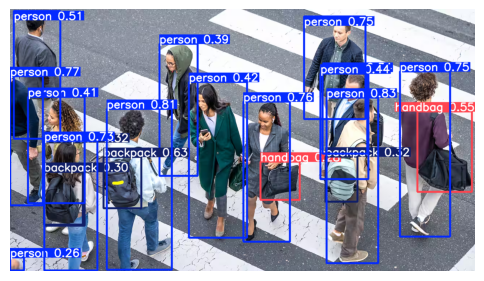

In [3]:
def predict_and_plot(model, img, conf=0.25, iou=0.7):
    """Realiza a predição usando o modelo YOLO e plota os resultados.
    
    O parâmetro `conf` define o limiar de probabilidade (chamado confiança) para considerar uma 
    detecção válida. 
    O parâmetro `iou` define o limiar de Interseção sobre União (IoU) para a supressão de 
    não-máximos, que é usada para eliminar detecções redundantes.
    """

    results = model.predict(
        source=img,
        conf=conf,
        iou=iou,
        end2end=False
    )

    img_res = results[0].plot()
    img_res = img_res[:, :, ::-1]  # Converte BGR para RGB

    plt.figure(figsize=(6, 8))
    plt.imshow(img_res)
    plt.axis("off")

predict_and_plot(model, img)

## Entendendo o modelo

In [6]:
# Informações sobre o treinamento do modelo
print("Tamanho de imagem usado no treinamento:", model.ckpt["train_args"]["imgsz"])
print("Classes usadas no treinamento:")
print(model.names)

Tamanho de imagem usado no treinamento: 640
Classes usadas no treinamento:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop

In [7]:
# Âncoras usadas no modelo
print("Número de âncoras:", model.model.model[-1].anchors.shape[1])
print("Resolução das âncoras (stride):", model.stride)

Número de âncoras: 5040
Resolução das âncoras (stride): tensor([ 8., 16., 32.])


Visualização da saída bruta (raw) do modelo:

In [5]:
import torch

img_tensor = model.predictor.preprocess([np.array(img)])

with torch.no_grad():
    raw_output = model.model(img_tensor)

output = raw_output[1]

boxes = output["boxes"]
scores = output["scores"]

print("Posições das caixas preditas:", boxes.shape)
print("Scores para as caixas preditas:", scores.shape)

Posições das caixas preditas: torch.Size([1, 4, 5040])
Scores para as caixas preditas: torch.Size([1, 80, 5040])


Portanto, para cada ponto âncora o modelo gera 4 valores indicando a posição prevista do objeto e os scores para cada uma das 80 classes do dataset COCO


0: 384x640 104 persons, 18 backpacks, 9 handbags, 6.8ms
Speed: 1.5ms preprocess, 6.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


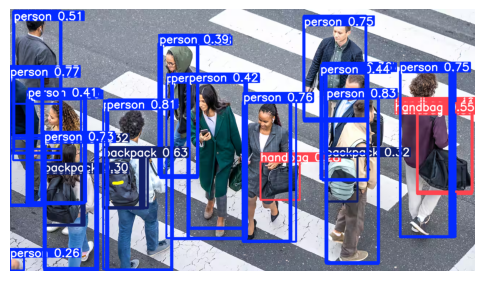

In [6]:
# Previsão sem aplicação de supressão de não-máximos (NMS)
predict_and_plot(model, img, conf=0.25, iou=1.0)

Em geral, diversas detecções ocorrem para o mesmo objeto. A supressão de não-máximos consiste em iterar sobre todas as caixas detectadas, começando da caixa com maior confiança, e remover todas as caixas com iou maior que um limiar com a caixa de maior confiança:

![nms](../data/notebook_images/nms.png)


0: 384x640 14 persons, 4 backpacks, 2 handbags, 3.0ms
Speed: 0.8ms preprocess, 3.0ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


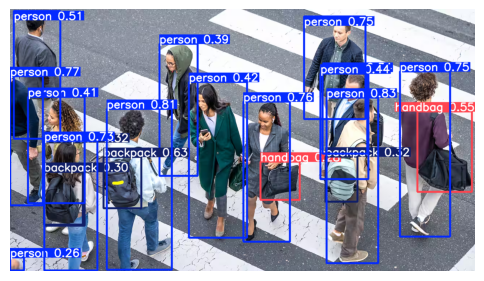

In [7]:
# Aplicação de supressão de não-máximos (NMS) com IoU de 0.7
predict_and_plot(model, img, conf=0.25, iou=0.7)

## Detalhe de como as imagens são redimensionadas

Antes de aplicar o modelo, a imagem é redimensionada mantendo o aspect ratio de forma que o maior lado seja igual a `imgsz`, o menor lado é redimensionado para o próximo múltiplo de 32 através do preenchimento com o valor 114.

In [8]:
shapes = [(360, 640), (640, 360), (360//2, 640//2), (360*2, 640*2)]

for shape in shapes:
    dummy_img = np.zeros((*shape, 3), dtype=np.uint8)
    img_t = model.predictor.pre_transform([dummy_img])[0]
    print(f"Original shape: {shape}, Transformed shape: {img_t.shape}")

Original shape: (360, 640), Transformed shape: (384, 640, 3)
Original shape: (640, 360), Transformed shape: (640, 384, 3)
Original shape: (180, 320), Transformed shape: (384, 640, 3)
Original shape: (720, 1280), Transformed shape: (384, 640, 3)


## Acessando os resultados do modelo

Cada caixa de resultado pode ser acessada através do atributo results.boxes

In [ ]:
results = model.predict(
        source=img,
        conf=0.25,
        iou=0.7,
        end2end=False
    )[0]

# Itera sobre as caixas preditas e imprime as informações relevantes
for id, box in enumerate(results.boxes):
    class_id = box.cls.item()
    # Nome da classe
    det_class = model.names[class_id]
    # Probabilidade / confiança da detecção
    prob = box.conf.item()
    # Coordenadas da caixa delimitadora no formato (x1, y1, x2, y2), onde (x1, y1) é o canto 
    # superior esquerdo e (x2, y2) é o canto inferior direito
    coords = box.xyxy[0].tolist()
    coords = [round(c) for c in coords]
    print(f"Caixa {id}: classe '{det_class}' com probabilidade {prob:.2f} na posição {coords}")
    


0: 384x640 14 persons, 4 backpacks, 2 handbags, 3.1ms
Speed: 0.8ms preprocess, 3.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Caixa 0: classe 'person' com probabilidade 0.83 na posição [871, 243, 1013, 699]
Caixa 1: classe 'person' com probabilidade 0.81 na posição [267, 275, 445, 717]
Caixa 2: classe 'person' com probabilidade 0.77 na posição [1, 184, 91, 539]
Caixa 3: classe 'person' com probabilidade 0.76 na posição [642, 255, 771, 640]
Caixa 4: classe 'person' com probabilidade 0.75 na posição [809, 21, 978, 303]
Caixa 5: classe 'person' com probabilidade 0.75 na posição [1074, 172, 1211, 625]
Caixa 6: classe 'person' com probabilidade 0.73 na posição [95, 363, 241, 718]
Caixa 7: classe 'backpack' com probabilidade 0.63 na posição [257, 406, 361, 548]
Caixa 8: classe 'handbag' com probabilidade 0.55 na posição [1121, 282, 1271, 503]
Caixa 9: classe 'person' com probabilidade 0.51 na posição [11, 6, 139, 357]
Caixa 10: classe 'person' com probabilidade 0.44 

Exemplo de processamento, obtenção da região da imagem contendo apenas a caixa:

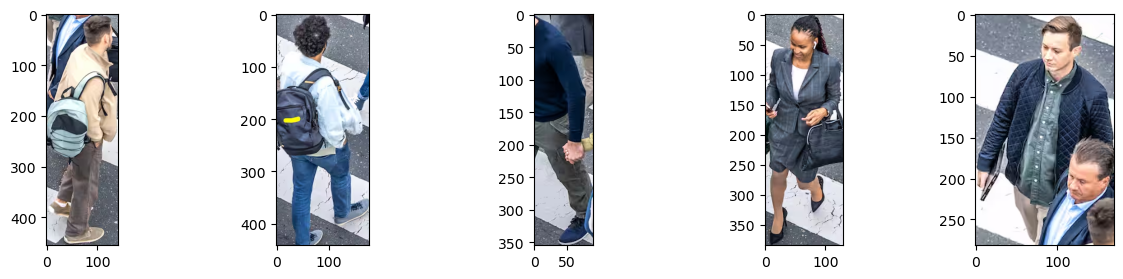

In [11]:
def crop_person(idx, results, img):
    coords = results[0].boxes[idx].xyxy[0].tolist()
    coords = [round(c) for c in coords]

    crop = img_np[coords[1]:coords[3], coords[0]:coords[2]]
    return crop

img_np = np.array(img)
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for idx, ax in zip(range(5), ax.flatten()):
    crop = crop_person(idx, results, img)
    ax.imshow(crop)